In [1]:
#Check our Colab environment
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
#LOAD A SMALL TINYSTORIES SUBSET
!pip -q install datasets

In [3]:
#LOAD THE DATASET
from datasets import load_dataset

dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train",
    streaming=True
)

print(dataset)

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

IterableDataset({
    features: ['text'],
    num_shards: 4
})


Look at the actual data

In [4]:
#LOOK AT THE ACTUAL TRAINING DATA
first_story = next(iter(dataset))


In [5]:
first_story

{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}

In [6]:
print(type(first_story))
print(first_story.keys())

print("\n--- STORY ---\n")
print(first_story["text"])

<class 'dict'>
dict_keys(['text'])

--- STORY ---

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


tokenize this one story

In [7]:
#tokenize this one story
#first install tiktoken

!pip -q install tiktoken

In [8]:
#the tokenizer creates the token_ids directly, the first step of creating the tokens first is not seen

import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

story_text = first_story["text"]
story_token_ids = tokenizer.encode(story_text)

print("Number of characters:", len(story_text))
print("Number of tokens:", len(story_token_ids))

print("\nFirst 20 token IDs:")
print(story_token_ids[:20])

Number of characters: 701
Number of tokens: 162

First 20 token IDs:
[3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408]


In [9]:
#decode those first 20 tokens so we can inspect them:
print("\nFirst 20 tokens:\n")

for token_id in story_token_ids[:20]:
    token = tokenizer.decode([token_id])
    print(f"{repr(token):10s} -> {token_id}")


First 20 tokens:

'One'      -> 3198
' day'     -> 1110
','        -> 11
' a'       -> 257
' little'  -> 1310
' girl'    -> 2576
' named'   -> 3706
' Lily'    -> 20037
' found'   -> 1043
' a'       -> 257
' needle'  -> 17598
' in'      -> 287
' her'     -> 607
' room'    -> 2119
'.'        -> 13
' She'     -> 1375
' knew'    -> 2993
' it'      -> 340
' was'     -> 373
' difficult' -> 2408


this tells us the first tinystories example has 162 gpt-2 tokens

In [10]:
#before choosing the context length let's see the story length
#Let's sample the first 1,000 stories and measure their GPT-2 token lengths.

#Because dataset is streaming, we'll use itertools.islice:

from itertools import islice

story_lengths = []

for example in islice(dataset, 1000):
    token_ids = tokenizer.encode(example["text"])
    story_lengths.append(len(token_ids))

print("Stories sampled:", len(story_lengths))
print("Shortest story:", min(story_lengths))
print("Longest story:", max(story_lengths))
print("Average tokens per story:", sum(story_lengths) / len(story_lengths))

Stories sampled: 1000
Shortest story: 70
Longest story: 986
Average tokens per story: 234.42


In [11]:
#calculate the percentile
import numpy as np

print("25th percentile:", np.percentile(story_lengths, 25))
print("50th percentile (median):", np.percentile(story_lengths, 50))
print("75th percentile:", np.percentile(story_lengths, 75))
print("90th percentile:", np.percentile(story_lengths, 90))
print("95th percentile:", np.percentile(story_lengths, 95))

25th percentile: 168.0
50th percentile (median): 199.0
75th percentile: 246.0
90th percentile: 398.1
95th percentile: 492.2499999999998


Now we have enough evidence to make the context-length choice deliberately.
The median story is about 199 tokens, the average is 234, and 75% are at or below 246 tokens. So context_length=128 is a sensible starting point for our T4.
A 128-token window won't hold most stories completely, but that's okay. During pretraining, we're learning next-token prediction from many chunks; we do not require every complete story to fit inside one context window.

Decide how much data to use

In [12]:
num_train_stories = 10_000
num_val_stories = 1_000

context_length = 128

print("Training stories:", num_train_stories)
print("Validation stories:", num_val_stories)
print("Context length:", context_length)

Training stories: 10000
Validation stories: 1000
Context length: 128


context length means the maximum number of tokens a model can process at once

For example, if a story has 500 tokens, our model cannot feed all 500 into one forward pass. We would work with windows/chunks such as:

Tokens 0–127

Tokens 128–255

Tokens 256–383

or overlapping windows, depending on how we construct the training data.

And during generation, it's the same idea. If we've generated 300 tokens but the model has a context length of 128, only up to the relevant 128-token context window can be supplied to our current model for the next prediction.

Context length is not how many tokens the model predicts. If we input 128 tokens during training, GPT produces a next-token prediction at each of those 128 positions in parallel (with causal masking preventing each position from seeing the future).

so our training tensor will be [B, 128]

Create separate training and validation data

Now we'll take 10,000 stories for training and a different 1,000 stories for validation.
Because our current dataset is streaming, let's extract the first 11,000 examples and then split them:

In [13]:
from itertools import islice

stories = list(
    islice(
        dataset,
        num_train_stories + num_val_stories
    )
)

train_stories = stories[:num_train_stories]
val_stories = stories[num_train_stories:]

print("Training stories:", len(train_stories))
print("Validation stories:", len(val_stories))

Training stories: 10000
Validation stories: 1000


Combine the training stories into a token stream

There are different ways to construct language-model training data. For this first pretraining experiment, we'll create one continuous training corpus, with an end-of-text token separating stories.

GPT-2 conveniently has a special token:<|endoftext|>

Story 1
<|endoftext|>
Story 2
<|endoftext|>
Story 3
<|endoftext|>
...

In [14]:
#let's first inspect it's ID
eot_token = "<|endoftext|>"
eot_id = tokenizer.encode(
    eot_token,
    allowed_special={eot_token}
)[0]

print("End-of-text token:", repr(eot_token))
print("Token ID:", eot_id)
print("Vocabulary size:", tokenizer.n_vocab)

End-of-text token: '<|endoftext|>'
Token ID: 50256
Vocabulary size: 50257


In [15]:
#WE PUT IT BETWEEN STORIES
#Without a boundary, our corpus could look like:
#...and they lived happily.One day a boy...
#AND THE MODEL HAS NO INDICATION THAT ONE DOCUMENT HAS ENDED


Tokenize the 10,000 training stories

In [16]:
train_token_ids = []

for story in train_stories:
    story_ids = tokenizer.encode(story["text"])

    train_token_ids.extend(story_ids)
    train_token_ids.append(eot_id) #after tokenizing the story, add the end of tect specila character

print("Number of training stories:", len(train_stories))
print("Total training tokens:", len(train_token_ids))

print("\nFirst 20 token IDs:")
print(train_token_ids[:20])

print("\nLast 20 token IDs:")
print(train_token_ids[-20:])

Number of training stories: 10000
Total training tokens: 2162078

First 20 token IDs:
[3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408]

Last 20 token IDs:
[290, 2695, 13, 1375, 550, 26338, 326, 673, 714, 2948, 1972, 1165, 3024, 416, 2712, 287, 262, 17979, 13, 50256]


Tokenize the validation stories

In [17]:
val_token_ids = []

for story in val_stories:
    story_ids = tokenizer.encode(story["text"])

    val_token_ids.extend(story_ids)
    val_token_ids.append(eot_id)

print("Number of validation stories:", len(val_stories))
print("Total validation tokens:", len(val_token_ids))

print("\nFirst 20 validation token IDs:")
print(val_token_ids[:20])

print("\nLast 20 validation token IDs:")
print(val_token_ids[-20:])

Number of validation stories: 1000
Total validation tokens: 181116

First 20 validation token IDs:
[7454, 612, 373, 257, 1310, 5916, 508, 5615, 287, 262, 9151, 13, 679, 2227, 284, 7301, 644, 373, 2029, 262]

Last 20 validation token IDs:
[14066, 329, 465, 17026, 290, 465, 890, 7405, 326, 4193, 683, 3613, 262, 6512, 290, 787, 649, 2460, 13, 50256]


so we have 2,162,078 training tokens

and 181,116 validation tokens

Understand one 128-token training example
Before creating thousands of examples, let's manually construct just the first one, exactly like Notebook 1.
Remember the pattern:

input={x_0, x_1,...., x_127}

target={x_1,x_2,....,x_128}

In [18]:
input_chunk = train_token_ids[:context_length]

target_chunk = train_token_ids[1 : context_length + 1]

print("Input length:", len(input_chunk))
print("Target length:", len(target_chunk))

print("\nFirst 10 input IDs:")
print(input_chunk[:10])

print("\nFirst 10 target IDs:")
print(target_chunk[:10])

Input length: 128
Target length: 128

First 10 input IDs:
[3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257]

First 10 target IDs:
[1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598]


Choose the stride

Recall that stride determines how far we move forward before creating the next training sequence.

If stride = 128, we'd get non-overlapping windows

If stride = 64, we'd get 50% overlap

In [19]:
#with stride = context_length
#Let's calculate approximately how many sequences that gives us before creating anything:

stride = context_length

num_train_sequences = (
    (len(train_token_ids) - context_length - 1) // stride
) + 1

num_val_sequences = (
    (len(val_token_ids) - context_length - 1) // stride
) + 1

print("Context length:", context_length)
print("Stride:", stride)

print("\nApprox. training sequences:", num_train_sequences)
print("Approx. validation sequences:", num_val_sequences)

Context length: 128
Stride: 128

Approx. training sequences: 16891
Approx. validation sequences: 1414


Create a memory-efficient Dataset

In Notebook 1, our GPTDataset pre-created and stored every input and target tensor. With millions of tokens, we don't need to duplicate everything like that.
Instead, we'll store the token stream once and create slices only when the DataLoader asks for them:

In [20]:
import torch
from torch.utils.data import Dataset

class GPTDataset(Dataset):

    def __init__(self, token_ids, context_length, stride):
        self.token_ids = torch.tensor(
            token_ids,
            dtype=torch.long
        )

        self.context_length = context_length
        self.stride = stride

    def __len__(self):
        return (
            (len(self.token_ids) - self.context_length - 1)
            // self.stride
        ) + 1

    def __getitem__(self, index):

        start = index * self.stride
        end = start + self.context_length

        input_ids = self.token_ids[start:end]

        target_ids = self.token_ids[start + 1:end + 1]

        return input_ids, target_ids

In [21]:
#Now instantiate both datasets:
train_dataset = GPTDataset(
    train_token_ids,
    context_length=context_length,
    stride=stride
)

val_dataset = GPTDataset(
    val_token_ids,
    context_length=context_length,
    stride=stride
)

print("Training sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))

Training sequences: 16891
Validation sequences: 1414


In [22]:
#Inspect Dataset examples
input_0, target_0 = train_dataset[0]
input_1, target_1 = train_dataset[1]

print("Example 0")
print("Input shape: ", input_0.shape)
print("Target shape:", target_0.shape)

print("\nExample 1")
print("Input shape: ", input_1.shape)
print("Target shape:", target_1.shape)

Example 0
Input shape:  torch.Size([128])
Target shape: torch.Size([128])

Example 1
Input shape:  torch.Size([128])
Target shape: torch.Size([128])


In [23]:
#verify the stride
print("Example 0 input — first 10 IDs:")
print(input_0[:10])

print("\nExample 0 input — last 10 IDs:")
print(input_0[-10:])

print("\nExample 1 input — first 10 IDs:")
print(input_1[:10])

Example 0 input — first 10 IDs:
tensor([ 3198,  1110,    11,   257,  1310,  2576,  3706, 20037,  1043,   257])

Example 0 input — last 10 IDs:
tensor([ 632,  373,  407, 2408,  329,  606,  780,  484,  547, 7373])

Example 1 input — first 10 IDs:
tensor([  290,  5742,  1123,   584,    13,  2293,   484,  5201,    11, 20037])


In [24]:
print("Input first 10:")
print(input_0[:10])

print("\nTarget first 10:")
print(target_0[:10])

print("\nShift correct?")
print(torch.equal(input_0[1:], target_0[:-1]))

Input first 10:
tensor([ 3198,  1110,    11,   257,  1310,  2576,  3706, 20037,  1043,   257])

Target first 10:
tensor([ 1110,    11,   257,  1310,  2576,  3706, 20037,  1043,   257, 17598])

Shift correct?
True


Create the DataLoaders

we introduce the batch dimension = 32

In [25]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 527
Validation batches: 45


In [26]:
#inspect one training batch
input_batch, target_batch = next(iter(train_loader))

print("Input batch shape: ", input_batch.shape)
print("Target batch shape:", target_batch.shape)

Input batch shape:  torch.Size([32, 128])
Target batch shape: torch.Size([32, 128])


Define our GPT configuration

In [27]:
GPT_CONFIG = {
    "vocab_size": 50257,
    "context_length": 128,
    "d_model": 128,
    "num_heads": 4,
    "num_layers": 4,
    "dropout": 0.1
}

GPT_CONFIG

{'vocab_size': 50257,
 'context_length': 128,
 'd_model': 128,
 'num_heads': 4,
 'num_layers': 4,
 'dropout': 0.1}

Multi-Head Attention with Dropout

In [28]:
import torch
import torch.nn as nn
import math

class MultiHeadAttention(nn.Module):
    def __init__(
        self,
        d_in,
        d_out,
        context_length,
        num_heads,
        dropout
    ):
        super().__init__()

        assert d_out % num_heads == 0

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)

        self.out_proj = nn.Linear(d_out, d_out, bias=False)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(context_length, context_length),
                diagonal=1
            )
        )

    def forward(self, x):

        B, T, _ = x.shape

        # 1. Create Q, K, V
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # 2. Split into attention heads
        queries = queries.view(B, T, self.num_heads, self.head_dim)
        keys    = keys.view(B, T, self.num_heads, self.head_dim)
        values  = values.view(B, T, self.num_heads, self.head_dim)

        queries = queries.transpose(1, 2)
        keys    = keys.transpose(1, 2)
        values  = values.transpose(1, 2)

        # 3. Attention scores
        attention_scores = queries @ keys.transpose(-2, -1)

        attention_scores = attention_scores / math.sqrt(self.head_dim)

        # 4. Causal mask
        attention_scores = attention_scores.masked_fill(
            self.mask[:T, :T].bool(),
            float("-inf")
        )

        # 5. Convert scores into attention probabilities
        attention_weights = torch.softmax(
            attention_scores,
            dim=-1
        )

        # NEW: dropout on attention weights
        attention_weights = self.dropout(attention_weights)

        # 6. Weighted combination of values
        context = attention_weights @ values

        # 7. Combine heads
        context = context.transpose(1, 2)
        context = context.contiguous().view(B, T, self.d_out)

        # 8. Output projection
        output = self.out_proj(context)

        return output

In [29]:
#Test Multi-Head Attention on a real batch
# Temporary embedding layer just for testing attention
test_embedding = nn.Embedding(
    GPT_CONFIG["vocab_size"],
    GPT_CONFIG["d_model"]
)

# Convert our real token IDs into vectors
x = test_embedding(input_batch) #takes in one input batch we created above

print("Token IDs shape:", input_batch.shape)
print("Embedded shape: ", x.shape)

Token IDs shape: torch.Size([32, 128])
Embedded shape:  torch.Size([32, 128, 128])


In [30]:
#test for positional embedding too
test_position_embedding = nn.Embedding(
    GPT_CONFIG["context_length"],
    GPT_CONFIG["d_model"]
)

# Token embeddings
token_embeddings = test_embedding(input_batch)

# Position IDs: 0, 1, 2, ..., 127
positions = torch.arange(
    input_batch.shape[1]
)

# Position embeddings
position_embeddings = test_position_embedding(positions)

# Combine them
x = token_embeddings + position_embeddings

print("Token embeddings shape:   ", token_embeddings.shape)
print("Position embeddings shape:", position_embeddings.shape)
print("Combined x shape:         ", x.shape)

print("\nFirst 10 position IDs:")
print(positions[:10])

Token embeddings shape:    torch.Size([32, 128, 128])
Position embeddings shape: torch.Size([128, 128])
Combined x shape:          torch.Size([32, 128, 128])

First 10 position IDs:
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [31]:
#After embedding, every token ID becomes a 128-dimensional learned vector:
#Pass the batch through 4-head causal attention
attention = MultiHeadAttention(
    d_in=GPT_CONFIG["d_model"],
    d_out=GPT_CONFIG["d_model"],
    context_length=GPT_CONFIG["context_length"],
    num_heads=GPT_CONFIG["num_heads"],
    dropout=GPT_CONFIG["dropout"]
)

attention_output = attention(x)

print("Input shape: ", x.shape)
print("Output shape:", attention_output.shape)

Input shape:  torch.Size([32, 128, 128])
Output shape: torch.Size([32, 128, 128])


In [32]:
#Build the Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

    def forward(self, x):
        return self.layers(x)

In [33]:
#test the ff with the combined token + position representations
ff = FeedForward(
    d_model=GPT_CONFIG["d_model"]
)

ff_output = ff(x)

print("Input shape: ", x.shape)
print("Output shape:", ff_output.shape)


Input shape:  torch.Size([32, 128, 128])
Output shape: torch.Size([32, 128, 128])


In [34]:
#Build one complete Transformer Block
class TransformerBlock(nn.Module):
    def __init__(
        self,
        d_model,
        context_length,
        num_heads,
        dropout
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.att = MultiHeadAttention(
            d_in=d_model,
            d_out=d_model,
            context_length=context_length,
            num_heads=num_heads,
            dropout=dropout
        )

        self.ff = FeedForward(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # ----- Attention sublayer -----
        shortcut = x

        x = self.norm1(x)
        x = self.att(x)
        x = self.dropout(x)

        x = x + shortcut

        # ----- Feed-forward sublayer -----
        shortcut = x

        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout(x)

        x = x + shortcut

        return x

In [35]:
#Let's first test one Transformer block on our real [32,128,128] representation:
test_block = TransformerBlock(
    d_model=GPT_CONFIG["d_model"],
    context_length=GPT_CONFIG["context_length"],
    num_heads=GPT_CONFIG["num_heads"],
    dropout=GPT_CONFIG["dropout"]
)

block_output = test_block(x)

print("Block input shape: ", x.shape)
print("Block output shape:", block_output.shape)

Block input shape:  torch.Size([32, 128, 128])
Block output shape: torch.Size([32, 128, 128])


now we have every component needed for GPT:embeddings, causal multi-head attention, FFN, LayerNorm, residual connections, and dropout.

In [36]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embedding = nn.Embedding(
            config["vocab_size"],
            config["d_model"]
        )

        self.position_embedding = nn.Embedding(
            config["context_length"],
            config["d_model"]
        )

        self.embedding_dropout = nn.Dropout(
            config["dropout"]
        )

        self.transformer_blocks = nn.Sequential(
            *[
                TransformerBlock(
                    d_model=config["d_model"],
                    context_length=config["context_length"],
                    num_heads=config["num_heads"],
                    dropout=config["dropout"]
                )
                for _ in range(config["num_layers"])
            ]
        )

        self.final_norm = nn.LayerNorm(
            config["d_model"]
        )

        self.output_head = nn.Linear(
            config["d_model"],
            config["vocab_size"],
            bias=False
        )

    def forward(self, token_ids):

        B, T = token_ids.shape

        # Token embeddings
        token_emb = self.token_embedding(token_ids)

        # Position embeddings
        positions = torch.arange(
            T,
            device=token_ids.device
        )

        pos_emb = self.position_embedding(positions)

        # Token + position
        x = token_emb + pos_emb

        # Dropout on input embeddings
        x = self.embedding_dropout(x)

        # 4 Transformer blocks
        x = self.transformer_blocks(x)

        # Final normalization
        x = self.final_norm(x)

        # Predict vocabulary logits
        logits = self.output_head(x)

        return logits

In [37]:
#Instantiate GPT and move it to the T4
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.manual_seed(42)

model = GPTModel(GPT_CONFIG)

model = model.to(device)

print("Device:", device)

Device: cuda


In [38]:
#Now count the trainable parameters:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     13,673,472
Trainable parameters: 13,673,472


In [39]:
#First complete forward pass
input_batch = input_batch.to(device)
target_batch = target_batch.to(device)

print("Input device: ", input_batch.device)
print("Target device:", target_batch.device)

with torch.no_grad():
    logits = model(input_batch)

print("\nInput shape: ", input_batch.shape)
print("Logits shape:", logits.shape)

Input device:  cuda:0
Target device: cuda:0

Input shape:  torch.Size([32, 128])
Logits shape: torch.Size([32, 128, 50257])


In [40]:
#Compute the initial cross-entropy loss
loss_fn = nn.CrossEntropyLoss()

loss = loss_fn(
    logits.flatten(0, 1),
    target_batch.flatten()
)

print("Initial loss:", loss.item())

Initial loss: 11.008785247802734


In [41]:
#Perform exactly ONE optimizer update
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.1
)

In [42]:
model.train()

# 1. Clear old gradients
optimizer.zero_grad()

# 2. Forward pass
logits = model(input_batch)

# 3. Calculate next-token loss
loss_before = loss_fn(
    logits.flatten(0, 1),
    target_batch.flatten()
)

# 4. Backpropagation
loss_before.backward()

# 5. Update all trainable parameters
optimizer.step()

print("Loss used for update:", loss_before.item())

Loss used for update: 11.006892204284668


In [43]:
#Re-evaluate after the update
model.eval()

with torch.no_grad():

    logits_after = model(input_batch)

    loss_after = loss_fn(
        logits_after.flatten(0, 1),
        target_batch.flatten()
    )

print("Loss after one update:", loss_after.item())

Loss after one update: 10.934223175048828


In [44]:
#Create a reusable loss function
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss

In [45]:
#Build the validation-loss evaluator
def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i >= num_batches:
            break

        loss = calc_loss_batch(
            input_batch,
            target_batch,
            model,
            device
        )

        total_loss += loss.item()

    return total_loss / num_batches

In [46]:
#test on 5 vlaidation batches
model.eval()

with torch.no_grad():

    val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
        num_batches=5
    )

print("Validation loss:", val_loss)

Validation loss: 10.964949226379394


In [47]:
#Write the real training loop
def train_model(model, train_loader,val_loader, optimizer, device, num_epochs, eval_freq=100, eval_batches=5):
    train_losses = []
    val_losses = []

    global_step = 0

    for epoch in range(num_epochs):

        # -------------------------
        # TRAINING
        # -------------------------
        model.train()

        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            loss.backward()

            optimizer.step()

            global_step += 1

            # -------------------------
            # PERIODIC EVALUATION
            # -------------------------
            if global_step % eval_freq == 0:

                model.eval()

                with torch.no_grad():

                    train_loss = calc_loss_loader(
                        train_loader,
                        model,
                        device,
                        num_batches=eval_batches
                    )

                    val_loss = calc_loss_loader(
                        val_loader,
                        model,
                        device,
                        num_batches=eval_batches
                    )

                train_losses.append(train_loss)
                val_losses.append(val_loss)

                print(
                    f"Epoch {epoch+1} | "
                    f"Step {global_step} | "
                    f"Train loss {train_loss:.4f} | "
                    f"Val loss {val_loss:.4f}"
                )

                # Switch dropout back on
                model.train()

    return train_losses, val_losses

In [48]:
#Reset the model for a clean pretraining run
torch.manual_seed(42)

model = GPTModel(GPT_CONFIG).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.1
)

print("Fresh model created.")
print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Fresh model created.
Parameters: 13,673,472


In [49]:
num_epochs = 3

print("Epochs:", num_epochs)
print("Batches per epoch:", len(train_loader))
print("Approx. optimizer steps:", num_epochs * len(train_loader))

Epochs: 3
Batches per epoch: 527
Approx. optimizer steps: 1581


In [50]:
#Launch real pretraining
train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=100,
    eval_batches=5
)

Epoch 1 | Step 100 | Train loss 6.0234 | Val loss 6.1928
Epoch 1 | Step 200 | Train loss 5.4582 | Val loss 5.6018
Epoch 1 | Step 300 | Train loss 4.9813 | Val loss 5.1827
Epoch 1 | Step 400 | Train loss 4.6841 | Val loss 4.8843
Epoch 1 | Step 500 | Train loss 4.4058 | Val loss 4.6857
Epoch 2 | Step 600 | Train loss 4.2896 | Val loss 4.5545
Epoch 2 | Step 700 | Train loss 4.1876 | Val loss 4.4442
Epoch 2 | Step 800 | Train loss 4.1059 | Val loss 4.3475
Epoch 2 | Step 900 | Train loss 3.9664 | Val loss 4.2624
Epoch 2 | Step 1000 | Train loss 3.8883 | Val loss 4.1908
Epoch 3 | Step 1100 | Train loss 3.8287 | Val loss 4.1303
Epoch 3 | Step 1200 | Train loss 3.7613 | Val loss 4.0899
Epoch 3 | Step 1300 | Train loss 3.7141 | Val loss 4.0346
Epoch 3 | Step 1400 | Train loss 3.7191 | Val loss 3.9949
Epoch 3 | Step 1500 | Train loss 3.6249 | Val loss 3.9484


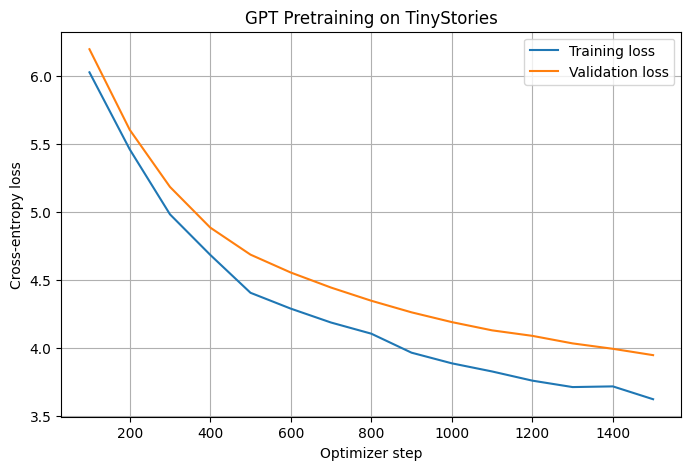

In [51]:
#Plot the learning curves
import matplotlib.pyplot as plt

steps = [
    100 * (i + 1)
    for i in range(len(train_losses))
]

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    train_losses,
    label="Training loss"
)

plt.plot(
    steps,
    val_losses,
    label="Validation loss"
)

plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title("GPT Pretraining on TinyStories")
plt.legend()
plt.grid()

plt.show()

In [52]:
#generate text from our gpt

#define he generation function
def generate_text_simple(
    model,
    input_ids,
    max_new_tokens,
    context_length
):
    model.eval()

    for _ in range(max_new_tokens):

        # Keep only tokens that fit inside the context window
        input_cond = input_ids[:, -context_length:]

        with torch.no_grad():
            logits = model(input_cond)

        # We only need the prediction at the final position
        logits = logits[:, -1, :]

        # Pick the token with the highest logit
        next_token_id = torch.argmax(
            logits,
            dim=-1,
            keepdim=True
        )

        # Append predicted token to the sequence
        input_ids = torch.cat(
            (input_ids, next_token_id),
            dim=1
        )

    return input_ids

In [53]:
#Actually generate from "Once upon a time"
prompt = "Once upon a time"

#first tokenize the prompt
prompt_ids = tokenizer.encode(prompt)

print("Prompt:", prompt)
print("Token IDs:", prompt_ids)
print("Number of prompt tokens:", len(prompt_ids))

Prompt: Once upon a time
Token IDs: [7454, 2402, 257, 640]
Number of prompt tokens: 4


In [54]:
#then convert the IDS into [batch, sequence] format

input_ids = torch.tensor(
    prompt_ids,
    dtype=torch.long
).unsqueeze(0).to(device)

print("Input shape:", input_ids.shape)
print("Input device:", input_ids.device)

Input shape: torch.Size([1, 4])
Input device: cuda:0


In [55]:
#Now generate 80 new tokens using the greedy function we just discussed:
generated_ids = generate_text_simple(
    model=model,
    input_ids=input_ids,
    max_new_tokens=80,
    context_length=GPT_CONFIG["context_length"]
)

print("Generated tensor shape:", generated_ids.shape)

Generated tensor shape: torch.Size([1, 84])


In [56]:
generated_ids

tensor([[ 7454,  2402,   257,   640,    11,   612,   373,   257,  1310,  2576,
          3706, 20037,    13,  1375,   373,   845,  3772,   290,   673,   550,
           257,  1263,  5509,    13,  1375,   373,   845,  3772,   290,   673,
           550,   257,  1263,  5509,    13,  1375,   373,   523,  3772,   326,
           673,   550,   257,  1263,    11,   673,   550,   257,  1263,  5509,
            13,  1375,   373,   523,  3772,   326,   673,   550,   257,  1263,
          8212,    13,  1375,   373,   523,  3772,   326,   673,   550,   257,
          1263,    11,   673,   550,   257,  1263,    11,   673,   550,   257,
          1263,  5509,    13,   198]], device='cuda:0')

In [57]:
#convert those token ids into readable text
generated_text = tokenizer.decode(
    generated_ids[0].tolist()
)

print(generated_text)

Once upon a time, there was a little girl named Lily. She was very happy and she had a big tree. She was very happy and she had a big tree. She was so happy that she had a big, she had a big tree. She was so happy that she had a big smile. She was so happy that she had a big, she had a big, she had a big tree.



In [58]:
#at this point gpt is stuck repeating itself because
#we Always choose the single highest-scoring token.\

#That sequence creates another context where the same high-probability choices become attractive again.

This means generation stragety matters instead of always choosing the highest probability toke, we can sample from the probability distribution

Sampling means "happy" remains most likely, but it isn't guaranteed.
That means two generations from the same prompt could diverge


And then temperature controls how adventurous that sampling is

Lower T makes the distribution sharper and more conservative. Higher T makes it flatter and more varied

In [59]:
#Implement Temperature Sampling
def generate_with_temperature(
    model,
    input_ids,
    max_new_tokens,
    context_length,
    temperature=1.0
):
    model.eval()

    for _ in range(max_new_tokens):

        # Keep only tokens that fit inside our context window
        input_cond = input_ids[:, -context_length:]

        # Get GPT's predictions
        with torch.no_grad():
            logits = model(input_cond)

        # We only need the prediction after the last token
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Convert logits into probabilities
        probabilities = torch.softmax(logits, dim=-1)

        # Sample ONE token according to those probabilities
        next_token_id = torch.multinomial(
            probabilities,
            num_samples=1
        )

        # Append the sampled token
        input_ids = torch.cat(
            (input_ids, next_token_id),
            dim=1
        )

    return input_ids

In [60]:
#test temperature = 1.0
prompt = "Once upon a time"

input_ids = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long
).unsqueeze(0).to(device)

generated_ids = generate_with_temperature(
    model=model,
    input_ids=input_ids,
    max_new_tokens=80,
    context_length=GPT_CONFIG["context_length"],
    temperature=1.0
)

generated_text = tokenizer.decode(
    generated_ids[0].tolist()
)

print(generated_text)

Once upon a time there was a icy to play with her mummy. She loved to work, but she broke her friends.

When Jane opened's mommy went home, she could do the people decided to panic. "Please fix restored thing!" 

Her mom asked her for, "This fun! Willter you like that is your friends were so we'll help me help you like you want to


Since we're repeatedly sampling tokens, occasionally one of those poor choices gets selected. Then there's an even bigger problem: that bad token becomes part of the context for the next prediction.

In [61]:
#try lower temperature
prompt = "Once upon a time"

input_ids = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long
).unsqueeze(0).to(device)

generated_ids = generate_with_temperature(
    model=model,
    input_ids=input_ids,
    max_new_tokens=80,
    context_length=GPT_CONFIG["context_length"],
    temperature=0.7
)

generated_text = tokenizer.decode(
    generated_ids[0].tolist()
)

print(generated_text)

Once upon a time, there was a girl named Lily. She loved to go to the park. She was very happy to the hug and she decided to be careful. She opened her friends, she was so happy, dancing and heard a bit dizz. She had a bright tree in a big hug. She was very happy. She was so sad and thanked the ground. One day, she saw a big kitchen.


In [62]:
#Add Top-p Sampling
prompt = "Once upon a time"

input_ids = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long
).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    logits = model(input_ids)

# Prediction for the next token only
next_token_logits = logits[:, -1, :]

# Use temperature 0.7
next_token_logits = next_token_logits / 0.7

# Convert to probabilities
probs = torch.softmax(next_token_logits, dim=-1)

# Sort from highest probability to lowest
sorted_probs, sorted_indices = torch.sort(
    probs,
    descending=True
)

# Calculate cumulative probabilities
cumulative_probs = torch.cumsum(
    sorted_probs,
    dim=-1
)

# Show the top 15 candidates
for i in range(15):
    token_id = sorted_indices[0, i].item()
    token = tokenizer.decode([token_id])
    prob = sorted_probs[0, i].item()
    cumulative = cumulative_probs[0, i].item()

    print(
        f"{i+1:2d}. {repr(token):15s} "
        f"prob={prob:.4f} "
        f"cumulative={cumulative:.4f}"
    )

 1. ','             prob=0.8687 cumulative=0.8687
 2. ' there'        prob=0.1223 cumulative=0.9910
 3. ' he'           prob=0.0024 cumulative=0.9934
 4. ' to'           prob=0.0019 cumulative=0.9954
 5. '.'             prob=0.0015 cumulative=0.9969
 6. ' she'          prob=0.0006 cumulative=0.9975
 7. ' when'         prob=0.0003 cumulative=0.9978
 8. ' the'          prob=0.0002 cumulative=0.9980
 9. ' for'          prob=0.0002 cumulative=0.9982
10. ' with'         prob=0.0002 cumulative=0.9983
11. ' in'           prob=0.0002 cumulative=0.9985
12. ' they'         prob=0.0001 cumulative=0.9986
13. ' a'            prob=0.0001 cumulative=0.9988
14. '!'             prob=0.0001 cumulative=0.9989
15. ' and'          prob=0.0001 cumulative=0.9990


In [63]:
#Find the cutoff automatically
top_p = 0.90

num_tokens_kept = (
    cumulative_probs[0] < top_p
).sum().item() + 1

print("Top-p:", top_p)
print("Number of tokens kept:", num_tokens_kept)

print("\nTokens inside the nucleus:")

for i in range(num_tokens_kept):
    token_id = sorted_indices[0, i].item()
    token = tokenizer.decode([token_id])
    prob = sorted_probs[0, i].item()
    cumulative = cumulative_probs[0, i].item()

    print(
        repr(token),
        f"prob={prob:.4f}",
        f"cumulative={cumulative:.4f}"
    )

Top-p: 0.9
Number of tokens kept: 2

Tokens inside the nucleus:
',' prob=0.8687 cumulative=0.8687
' there' prob=0.1223 cumulative=0.9910


In [64]:
#Build Top-p Generation
def generate_with_top_p(
    model,
    input_ids,
    max_new_tokens,
    context_length,
    temperature=1.0,
    top_p=0.9
):
    model.eval()

    for _ in range(max_new_tokens):

        # 1. Keep only the context window
        input_cond = input_ids[:, -context_length:]

        # 2. Get GPT predictions
        with torch.no_grad():
            logits = model(input_cond)

        # 3. Prediction for next token only
        logits = logits[:, -1, :]

        # 4. Apply temperature
        logits = logits / temperature

        # 5. Convert logits to probabilities
        probs = torch.softmax(logits, dim=-1)

        # 6. Sort probabilities highest -> lowest
        sorted_probs, sorted_indices = torch.sort(
            probs,
            descending=True
        )

        # 7. Calculate cumulative probabilities
        cumulative_probs = torch.cumsum(
            sorted_probs,
            dim=-1
        )

        # 8. Find tokens outside the top-p nucleus
        remove_mask = cumulative_probs > top_p

        # Keep the first token that crosses the threshold
        remove_mask[:, 1:] = remove_mask[:, :-1].clone()
        remove_mask[:, 0] = False

        # 9. Set removed token probabilities to zero
        sorted_probs[remove_mask] = 0.0

        # 10. Renormalize remaining probabilities
        sorted_probs = (
            sorted_probs /
            sorted_probs.sum(dim=-1, keepdim=True)
        )

        # 11. Sample from the nucleus
        sampled_position = torch.multinomial(
            sorted_probs,
            num_samples=1
        )

        # 12. Convert sorted position back to real token ID
        next_token_id = torch.gather(
            sorted_indices,
            dim=-1,
            index=sampled_position
        )

        # Stop if GPT predicts end-of-text
        if next_token_id.item() == eot_id:
          break

        # 13. Append generated token
        input_ids = torch.cat(
            (input_ids, next_token_id),
            dim=1
        )

    return input_ids

In [65]:
#generate
prompt = "Once upon a time"

input_ids = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long
).unsqueeze(0).to(device)

generated_ids = generate_with_top_p(
    model=model,
    input_ids=input_ids,
    max_new_tokens=80,
    context_length=GPT_CONFIG["context_length"],
    temperature=0.7,
    top_p=0.9
)

generated_text = tokenizer.decode(
    generated_ids[0].tolist()
)

print(generated_text)

Once upon a time there was a little girl named Lily. She had a big smile. One day, she saw a little girl. She was a big dog, but she was very friendly. She saw a little girl named Lily. She knew she was very kind. She couldn't find her mom and put her to make them. She wanted to get the trees and let her mom said, "That's a great


In [66]:
#validation loss accross all validation batches
model.eval()

with torch.no_grad():
    final_val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
        num_batches=None
    )

print("Final full validation loss:", final_val_loss)

Final full validation loss: 3.6398487620883517


In [67]:
#calculate PERPLEXITY
import math

final_val_perplexity = math.exp(final_val_loss)

print("Validation loss:", final_val_loss)
print("Validation perplexity:", final_val_perplexity)

Validation loss: 3.6398487620883517
Validation perplexity: 38.086076231175355


which you can interpret loosely as the model having next-token uncertainty comparable to choosing among roughly 38 equally probable alternatives on the held-out TinyStories data.

so perplexity isn't a completely separate measurement—it is an easier-to-interpret transformation of cross-entropy loss.
For our model, 38.09 does not mean GPT literally chooses among exactly 38 tokens at every step. The vocabulary still contains 50,257 tokens. Rather, its average uncertainty on this validation corpus is comparable to an idealized situation with about 38 equally plausible choices.

The next useful evaluation concept is the training–validation gap and overfitting: using both losses together to determine whether more training is helping generalization or mostly memorizing the training corpus.

Training Loss vs Validation Loss and Overfitting

In [68]:
#Save the Pretrained GPT Checkpoin
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG,
    "validation_loss": final_val_loss,
    "validation_perplexity": final_val_perplexity
}

torch.save(
    checkpoint,
    "tinystories_gpt_checkpoint.pth"
)

print("Checkpoint saved!")

Checkpoint saved!


In [69]:
#Load the checkpoint into a fresh model
new_model = GPTModel(GPT_CONFIG).to(device)

print("Fresh model created.")

Fresh model created.


In [70]:
#load the checkpoint
loaded_checkpoint = torch.load(
    "tinystories_gpt_checkpoint.pth",
    map_location=device
)

print(loaded_checkpoint.keys())

dict_keys(['model_state_dict', 'optimizer_state_dict', 'config', 'validation_loss', 'validation_perplexity'])


In [71]:
new_model.load_state_dict(
    loaded_checkpoint["model_state_dict"]
)

new_model.eval()

print("Trained weights loaded successfully!")

Trained weights loaded successfully!


In [72]:
prompt = "Once upon a time"

input_ids = torch.tensor(
    tokenizer.encode(prompt),
    dtype=torch.long
).unsqueeze(0).to(device)

generated_ids = generate_with_top_p(
    model=new_model,
    input_ids=input_ids,
    max_new_tokens=80,
    context_length=GPT_CONFIG["context_length"],
    temperature=0.7,
    top_p=0.9
)

generated_text = tokenizer.decode(
    generated_ids[0].tolist()
)

print(generated_text)

Once upon a time, there was a little girl who loved to play with her house. She was so excited to play with her room. She was very happy that she had never just so much fun.

The girl was so proud of the big hug. She saw something special ball and couldn't know what she had a loud noise. She wanted to eat it and wanted to help her mommy's eyes.
